# 03 — Magnus effect: fastball vs curveball

Why does a 4-seam fastball seem to *rise*, while a curveball drops more than gravity alone would explain? The answer is the Magnus force, and the only difference between the two pitches in this notebook is the direction of the spin axis. Everything else (drag, gravity, atmosphere) is identical.

We'll simulate both pitches, plot their trajectories from multiple angles, and decompose the forces over time.

Reference: SPEC §4.1 'A fastball does not rise; it drops less.'

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pitchphys import simulate
from pitchphys.presets import curveball, four_seam
from pitchphys.viz.plot2d import compare_pitches
from pitchphys.viz.plot3d import compare_pitches_3d

## 1. Build the two pitches

A 95 mph 12:00-tilt 4-seamer (pure backspin) versus an 80 mph 6:00-tilt curveball (pure topspin). Defaults match the league archetypes.

In [2]:
fb = four_seam(speed_mph=95, spin_rpm=2400, tilt_clock=12.0)
cb = curveball(speed_mph=80, spin_rpm=2700, tilt_clock=6.0)
fb, cb

(PitchRelease(speed_m_s=42.4688, launch_angle_deg=-1.0, horizontal_angle_deg=0.0, release_pos_m=array([-0.4572,  0.    ,  1.8288]), spin_rate_rad_s=251.32741228718345, spin_axis=array([ 0.95      ,  0.31220234, -0.00544951]), active_spin_fraction=0.95, metadata={'extension_ft': 6.0, 'throwing_hand': 'R', 'tilt_clock': 12.0}),
 PitchRelease(speed_m_s=35.7632, launch_angle_deg=-1.0, horizontal_angle_deg=0.0, release_pos_m=array([-0.4572,  0.    ,  1.8288]), spin_rate_rad_s=282.7433388230814, spin_axis=array([-0.85      ,  0.52670246, -0.00919363]), active_spin_fraction=0.85, metadata={'extension_ft': 6.0, 'throwing_hand': 'R', 'tilt_clock': 6.0}))

## 2. Simulate

In [3]:
traj_fb = simulate(fb)
traj_cb = simulate(cb)
for label, traj in [("Fastball", traj_fb), ("Curveball", traj_cb)]:
    print(
        f"{label:<10} "
        f"release {traj.release_speed_mph:.1f} mph -> "
        f"plate {traj.plate_speed_mph:.1f} mph, "
        f"IVB {traj.induced_vertical_break_in:+.1f} in, "
        f"flight {traj.flight_time_s:.2f} s"
    )

Fastball   release 95.0 mph -> plate 86.5 mph, IVB +20.5 in, flight 0.41 s
Curveball  release 80.0 mph -> plate 73.6 mph, IVB -19.1 in, flight 0.49 s


Notice the IVB signs. Positive IVB means the pitch ends up *above* a no-force projectile launched with the same release velocity — i.e., the Magnus force lifted the ball. Negative IVB means the Magnus force pushed it down beyond gravity's drop.

## 3. Catcher view + side view

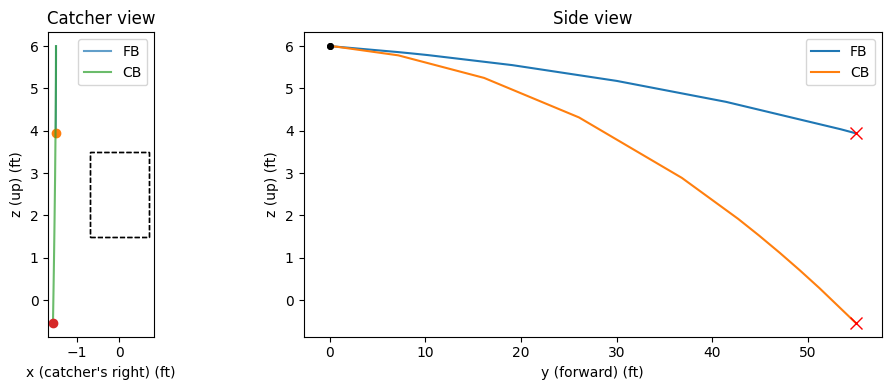

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
compare_pitches([traj_fb, traj_cb], view="catcher", labels=["FB", "CB"], ax=axes[0])
axes[0].set_title("Catcher view")
compare_pitches([traj_fb, traj_cb], view="side", labels=["FB", "CB"], ax=axes[1])
axes[1].set_title("Side view")
fig.tight_layout()
plt.show()

From the catcher's view both pitches end near the strike zone, but the side view shows the dramatic difference: the fastball is ~20 in. higher at the plate than the curveball, despite being released from the same height. That ~20 in. is the difference Magnus makes.

## 4. Interactive 3D

In [5]:
fig3d = compare_pitches_3d([traj_fb, traj_cb], labels=["Fastball", "Curveball"])
fig3d.show()

## 5. Force magnitudes over time

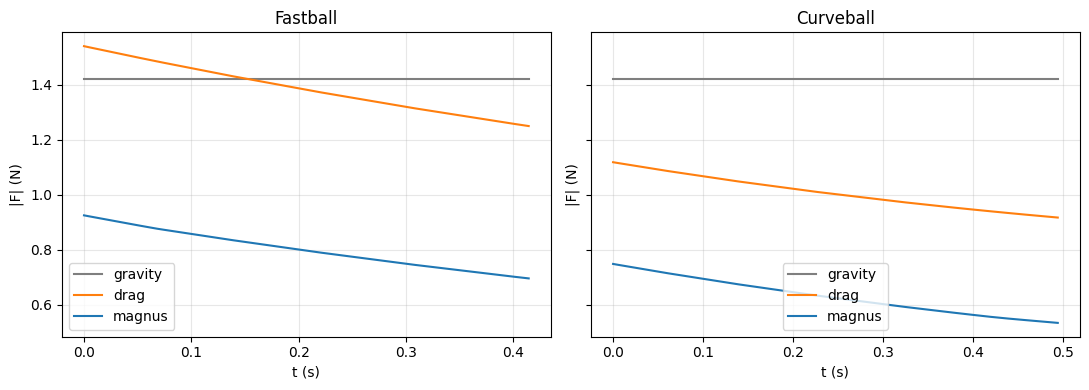

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, traj) in zip(axes, [("Fastball", traj_fb), ("Curveball", traj_cb)], strict=False):
    for fname, color in [("gravity", "tab:gray"), ("drag", "tab:orange"), ("magnus", "tab:blue")]:
        mag = np.linalg.norm(traj.forces[fname], axis=1)
        ax.plot(traj.time, mag, label=fname, color=color)
    ax.set_title(name)
    ax.set_xlabel("t (s)")
    ax.set_ylabel("|F| (N)")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Gravity is constant at `m·g ≈ 1.42 N` throughout. Drag and Magnus scale with `|v|^2`, so they decline as the pitch slows. The fastball shows a larger Magnus force (positive sign perpendicular to velocity, lifting the ball); the curveball's Magnus force is similar in magnitude but oriented downward.

## Takeaway

The fastball never literally *rises*. Gravity always pulls it down. But the Magnus force counteracts a portion of gravity's drop, so the ball ends up ~20 in. higher than a spinless equivalent — enough to look like a 'rise' to the hitter. The curveball does the opposite: Magnus and gravity work *together*, and the ball drops dramatically.